# Assignment Answers

I am still using the same general baseline idea as the original notebook:
- tabular data from `BostonHousing.csv`
- a simple regression neural network
- train / validation / test split
- evaluate the predictions at the end

The difference is that here I focus directly on the questions I was asked to think about.

## The three questions I am answering
1. A visualization of the errors at the end would be interesting.  
2. Calculating the R² and the RMSE of this model would help judging the model's performance. What do their values mean in relation to the case?  
3. Regression models can be sensitive to the data being distributed normally. Is it in this project? If not, what can we do?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
import torch.utils.data as D
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PowerTransformer
from scipy import stats

torch.manual_seed(0)
np.random.seed(0)


# Load the data

I start by loading the same CSV that is used in the original lab.


In [2]:
possible_paths = [
    Path("../../references/house_price_predictor/BostonHousing.csv"),
    Path("references/house_price_predictor/BostonHousing.csv"),
    Path("BostonHousing.csv"),
]

csv_path = None
for p in possible_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("BostonHousing.csv was not found. Check the notebook location.")

df = pd.read_csv(csv_path)
print("Using dataset from:", csv_path)
print("Shape:", df.shape)
display(df.head())


Using dataset from: ..\..\references\house_price_predictor\BostonHousing.csv
Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### My quick reading of the data

Each row is one house.  
The first 13 columns are the clues.  
The last column, `medv`, is the price I want to predict.


# Recreate the baseline model

To make my answers reproducible, I rebuild the same simple approach:
- split the data
- define the model
- train it
- predict on the test set


In [3]:
class TabularDataset(D.TensorDataset):
    def __init__(self, dataframe):
        tensor = torch.tensor(dataframe.values, dtype=torch.float32)
        x = tensor[:, :-1]
        y = tensor[:, -1]
        super().__init__(x, y)

    def num_features(self):
        return self.tensors[0].shape[1]


class RegressionModel(L.LightningModule):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.criterion = nn.MSELoss()

    def forward(self, x):
        return self.model(x).view(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.criterion(preds, y)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.criterion(preds, y)
        self.log("val_loss", loss, prog_bar=False)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)


In [4]:
dataset = TabularDataset(df)
train_ds, val_ds, test_ds = D.random_split(dataset, [0.6, 0.3, 0.1])

datamodule = L.LightningDataModule.from_datasets(
    train_ds,
    val_ds,
    test_ds,
    batch_size=32,
    num_workers=0
)

print("Number of features:", dataset.num_features())
print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))


Number of features: 13
Train size: 304
Validation size: 152
Test size: 50


In [5]:
model = RegressionModel(num_features=dataset.num_features())

trainer = L.Trainer(
    max_epochs=200,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, mode="min")],
    enable_checkpointing=False,
    logger=False,
    enable_progress_bar=False
)

trainer.fit(model, datamodule=datamodule)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name      | Type       | Params | Mode  | FLOPs
---------------------------------------------------------
0 | model     | Sequential | 961    | train | 0    
1 | criterion | MSELoss    | 0      | train | 0    
---------------------------------------------------------
961       Trainable params
0         Non-trainable params
961       Total params
0.004     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops
C:\Users\eduar\Documents\ai-lab-assignments\myvenv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespe

In [6]:
# Collect truth and predictions from the test split
test_loader = datamodule.test_dataloader()

truth_list = []
pred_list = []

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        preds = model(x_batch)
        truth_list.extend(y_batch.numpy())
        pred_list.extend(preds.numpy())

results = pd.DataFrame({
    "truth": np.array(truth_list),
    "prediction": np.array(pred_list)
})
results["error"] = results["truth"] - results["prediction"]
results["absolute_error"] = results["error"].abs()

display(results.head())


,truth,prediction,error,absolute_error
0,18.5,12.999203,5.500797,5.500797
1,27.1,23.325584,3.774416,3.774416
2,22.6,21.618786,0.981215,0.981215
3,14.3,16.749586,-2.449586,2.449586
4,25.0,24.927797,0.072203,0.072203


# Question 1  
## A visualization of the errors at the end would be interesting.

My answer is yes, definitely.  
The original notebook already compares truth and prediction, but I think the model's mistakes become much easier to understand if I also visualize the errors directly.

So I am adding four views:
1. truth vs prediction  
2. histogram of absolute errors  
3. residual plot  
4. biggest mistakes


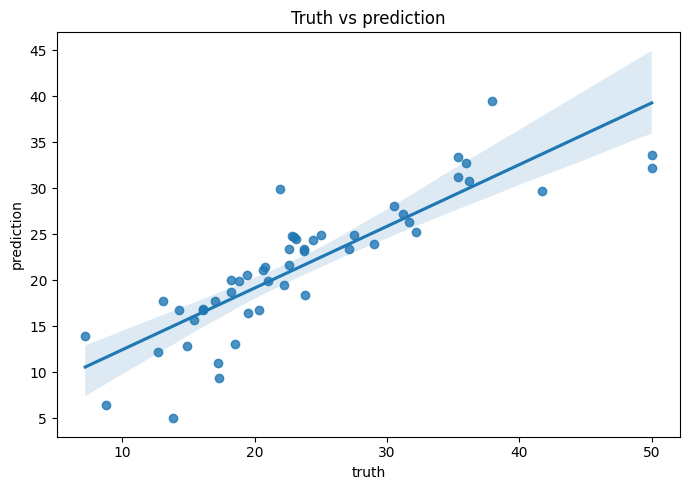

In [7]:
plt.figure(figsize=(7, 5))
sns.regplot(data=results, x="truth", y="prediction")
plt.title("Truth vs prediction")
plt.tight_layout()
plt.show()


### What I see here

If the model was perfect, the points would line up very tightly.  
Instead, I can already see that the model is decent in the middle range but struggles more at the extremes.

That means the model is not useless, but it also is not perfectly calibrated across the whole price range.


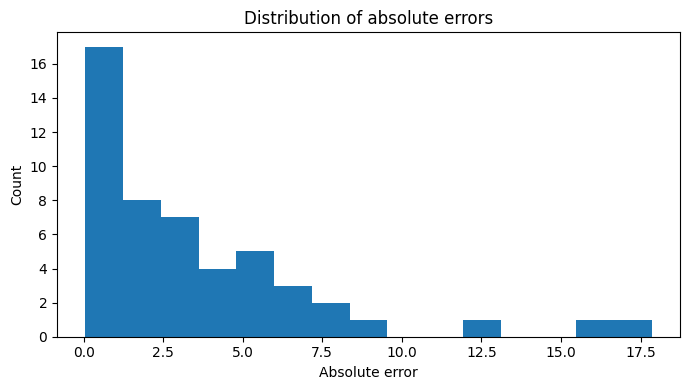

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(results["absolute_error"], bins=15)
plt.xlabel("Absolute error")
plt.ylabel("Count")
plt.title("Distribution of absolute errors")
plt.tight_layout()
plt.show()


### Why this plot helps me more

This is useful because now I can see whether the model usually makes small mistakes and only sometimes makes huge ones, or whether it is consistently messy.

This is much more informative than only saying “the predictions are not perfect.”


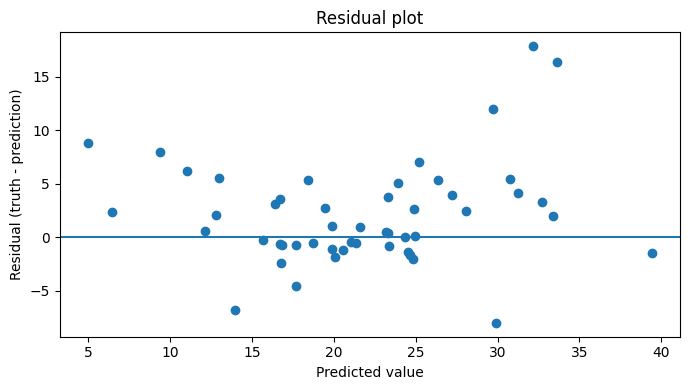

In [9]:
plt.figure(figsize=(7, 4))
plt.axhline(0)
plt.scatter(results["prediction"], results["error"])
plt.xlabel("Predicted value")
plt.ylabel("Residual (truth - prediction)")
plt.title("Residual plot")
plt.tight_layout()
plt.show()


### Why residuals matter

Residuals show the direction of the mistake:
- positive residual = the model predicted too low
- negative residual = the model predicted too high

If the residuals were nicely centered around zero with no obvious structure, that would be cleaner.  
If I see patterns, then the model is missing something systematic.


,truth,prediction,error,absolute_error
0,50.000000,32.150581,17.849419,17.849419
1,50.000000,33.605171,16.394829,16.394829
2,41.700001,29.706995,11.993006,11.993006
3,13.800000,4.971429,8.828571,8.828571
4,21.900000,29.901489,-8.001490,8.001490
5,17.299999,9.356778,7.943221,7.943221
6,32.200001,25.208828,6.991173,6.991173
7,7.200000,13.953080,-6.753080,6.753080
8,17.200001,11.029080,6.170920,6.170920
9,18.500000,12.999203,5.500797,5.500797


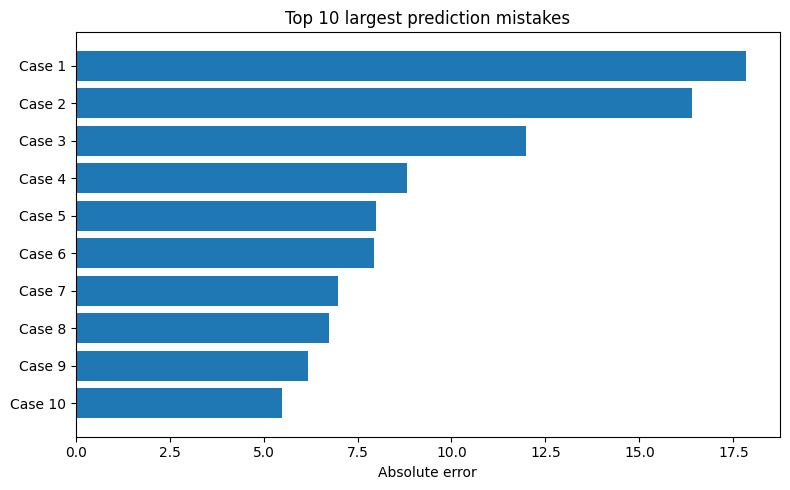

In [10]:
largest_errors = results.sort_values("absolute_error", ascending=False).head(10).reset_index(drop=True)
display(largest_errors)

plt.figure(figsize=(8, 5))
plt.barh(range(len(largest_errors)), largest_errors["absolute_error"])
plt.yticks(range(len(largest_errors)), [f"Case {i+1}" for i in range(len(largest_errors))])
plt.xlabel("Absolute error")
plt.title("Top 10 largest prediction mistakes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## My answer to Question 1

Yes, an error visualization is useful and I would say it should be included.

The truth-vs-prediction graph gives a general feeling, but the histogram of absolute errors and the residual plot make the model's behavior much easier to judge.

From these plots I can explain the case better:
- the model is usually closer in the middle range
- some houses produce much larger mistakes
- the extreme prices are more difficult for the model

# Question 2  
## Calculating the R² and the RMSE of this model would help judging the model's performance. What do their values mean in relation to the case?

I agree.  
R² and RMSE complement each other, so using both gives a fuller picture.


In [11]:
r2 = r2_score(results["truth"], results["prediction"])
rmse = np.sqrt(mean_squared_error(results["truth"], results["prediction"]))
mae = results["absolute_error"].mean()
mean_target = results["truth"].mean()

print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"Mean target value: {mean_target:.4f}")
print(f"RMSE as % of mean target: {rmse / mean_target * 100:.2f}%")


R²   : 0.6785
RMSE : 5.2479
MAE  : 3.5965
Mean target value: 23.7960
RMSE as % of mean target: 22.05%


## How I interpret these metrics

`R²` tells me how much of the price pattern the model explains.  
A value closer to `1` is better.  
A value around `0` would mean the model is not really doing better than a naive baseline that predicts the mean.  
A negative value would mean the model is performing worse than that naive baseline.

`RMSE` tells me the typical size of the mistake in the same unit as the target.  
That is useful because it makes the error feel more concrete.

So together they answer two different questions:
- **R²**: does the model understand the pattern?
- **RMSE**: how big are the mistakes in practice?

If my R² is positive and reasonably far from zero, then the model is learning something.  
If my RMSE is still large, then I know that even though it captures part of the pattern, the actual prediction mistakes can still be substantial.

That is exactly the situation I expect in this case:
the model is useful as a beginner baseline, but not strong enough to be trusted blindly for real decision making.


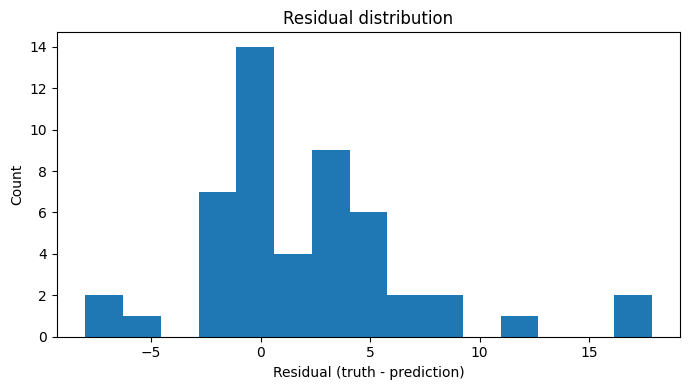

In [12]:
plt.figure(figsize=(7, 4))
plt.hist(results["error"], bins=15)
plt.xlabel("Residual (truth - prediction)")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.tight_layout()
plt.show()


## My answer to Question 2

I would use both R² and RMSE.

R² tells me whether the model captured a meaningful part of the relationship between house features and house prices.

RMSE tells me the size of the model's prediction mistakes in the same price unit as the dataset.

So even if the R² is decent, a large RMSE would still warn me that the model can miss the real price by quite a lot on some houses.

# Question 3  
## Regression models can be sensitive to the data being distributed normally. Is it in this project? If not, what can we do?

To answer this, I first want evidence instead of guessing.

I will inspect the target distribution, the skewness of the columns, and then compare one skewed feature before and after transformation.


In [13]:
feature_columns = [col for col in df.columns if col != "medv"]

skewness = df[feature_columns + ["medv"]].skew().sort_values(key=lambda s: s.abs(), ascending=False)
display(skewness.to_frame("skewness"))


,skewness
crim,5.223149
chas,3.405904
b,-2.890374
zn,2.225666
medv,1.108098
dis,1.011781
rad,1.004815
lstat,0.906460
ptratio,-0.802325
nox,0.729308


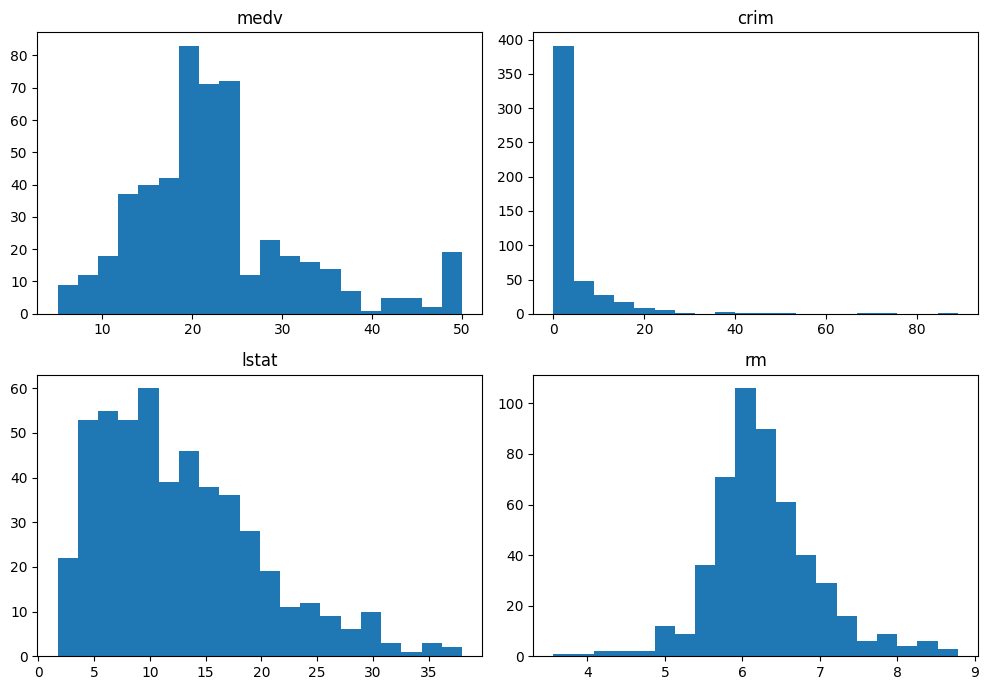

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

columns_to_plot = ["medv", "crim", "lstat", "rm"]

for ax, col in zip(axes.ravel(), columns_to_plot):
    ax.hist(df[col], bins=20)
    ax.set_title(col)

plt.tight_layout()
plt.show()


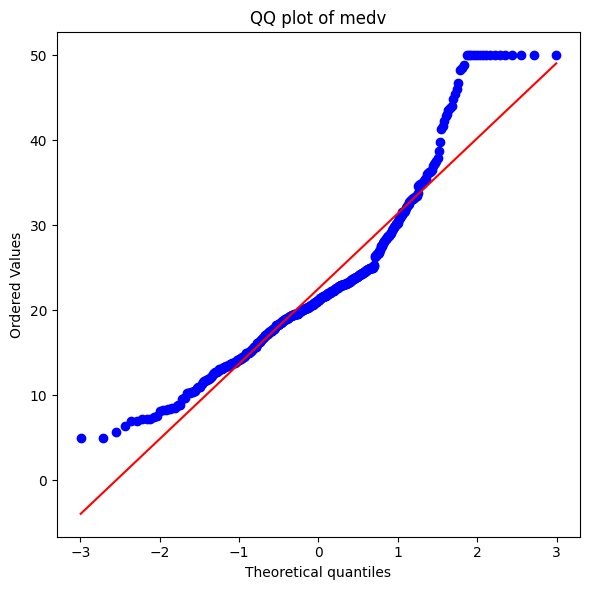

In [15]:
plt.figure(figsize=(6, 6))
stats.probplot(df["medv"], dist="norm", plot=plt)
plt.title("QQ plot of medv")
plt.tight_layout()
plt.show()


### What I notice

I do not think the data is nicely normal overall.

Some columns look far more skewed than others, and the target `medv` is not a perfect bell-shaped distribution either.

That does not automatically mean the model becomes useless.  
But it does mean that the data is not especially clean and symmetric, so some features may benefit from transformation.


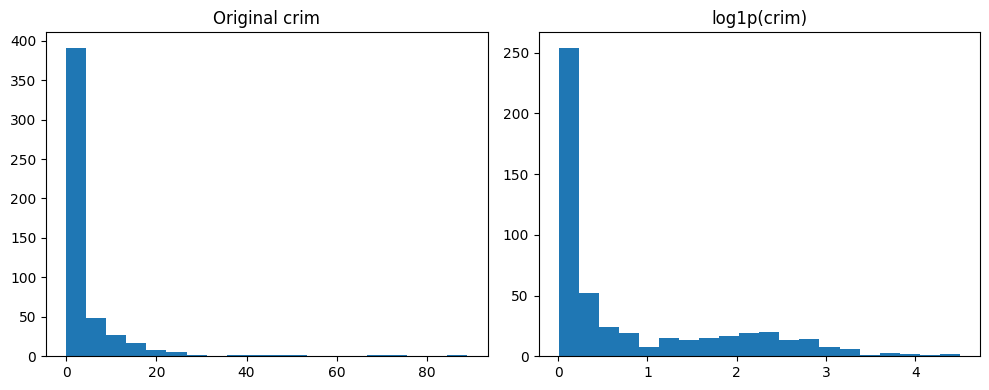

Original skewness of crim   : 5.223148798243851
Skewness after log1p(crim)  : 1.2692005882725572


In [16]:
transformed_df = df.copy()
transformed_df["crim_log1p"] = np.log1p(transformed_df["crim"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["crim"], bins=20)
axes[0].set_title("Original crim")
axes[1].hist(transformed_df["crim_log1p"], bins=20)
axes[1].set_title("log1p(crim)")
plt.tight_layout()
plt.show()

print("Original skewness of crim   :", df["crim"].skew())
print("Skewness after log1p(crim)  :", transformed_df["crim_log1p"].skew())


In [17]:
pt = PowerTransformer()
X_transformed = pt.fit_transform(df[feature_columns])
transformed_features = pd.DataFrame(X_transformed, columns=feature_columns)

comparison = pd.DataFrame({
    "original_skewness": df[feature_columns].skew(),
    "after_power_transform": transformed_features.skew()
}).sort_values("original_skewness", key=lambda s: s.abs(), ascending=False)

display(comparison.head(10))


,original_skewness,after_power_transform
crim,5.223149,0.595482
chas,3.405904,3.405904
b,-2.890374,-1.908672
zn,2.225666,1.071695
dis,1.011781,0.067176
rad,1.004815,0.065818
lstat,0.906460,-0.017928
ptratio,-0.802325,-0.220097
nox,0.729308,0.098431
tax,0.669956,0.079614


## My answer to Question 3

No, I would not say the data in this project is nicely normally distributed.

Some variables are clearly skewed, and that matters because regression models can become more sensitive to outliers and awkward distributions.

If I want to improve the situation, I could:
- transform strongly skewed features, for example with `log1p`
- use a more general transformation such as `PowerTransformer`
- inspect outliers more carefully
- consider feature scaling and preprocessing before training

I would not claim that “everything must be perfectly normal or the model dies.”  
That would be too dramatic.

My real conclusion is:
the data is not especially normal, and transforming skewed variables is a reasonable next improvement step.

# Final conclusion

My final verdict is that the original notebook is a good beginner starting point, but the three improvement questions are valid.

### What I added
For the first question, I added more direct error visualizations.  
For the second question, I calculated R² and RMSE and explained what they mean in relation to the case.  
For the third question, I checked the distribution of the data and showed that at least some variables are skewed, so transformations could help.